# 09 — Representation Learning Made Visible (TensorFlow / Keras)


> **Learning contract.** Every code cell is preceded by an explanation of what the code does, why the operation exists mathematically, what tensor/array shapes are expected, and what production or business failure it prevents. Run the notebooks in numerical order in a fresh Conda environment.


Representation learning means the network changes the coordinates used to describe the same sample. To make that geometric process observable, this lab constrains the hidden layer to **two neurons**: $h=\phi(XW+b)\in\mathbb{R}^2$. The output layer must classify from those two learned coordinates.

A useful representation moves samples so useful classes become easier to separate. We save the coordinates of the **same 1,500 training samples** at several epochs, so movement is not confused with resampling.


## Code walkthrough — train a deliberately narrow 2D bottleneck
The bottleneck sacrifices accuracy for interpretability. Snapshots at epochs 0, 1, 3, 7 and 15 let us see the geometry being rewritten by gradient updates.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

tf.random.set_seed(42)
from pathlib import Path
import urllib.request
import numpy as np
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / "mnist.npz"
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"


def load_official_mnist():
    if not MNIST_PATH.exists():
        print("Downloading official MNIST archive to", MNIST_PATH)
        urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
    with np.load(MNIST_PATH) as data:
        return (data["x_train"], data["y_train"], data["x_test"], data["y_test"])


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    selected = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        selected.extend(rng.choice(candidates, size=per_class, replace=False))
    selected = np.asarray(selected)
    rng.shuffle(selected)
    return (x[selected], y[selected])


def prepare_splits():
    x_train_raw, y_train_raw, x_test_raw, y_test_raw = load_official_mnist()
    x_dev, y_dev = balanced_subset(x_train_raw, y_train_raw, per_class=600)
    x_test, y_test = balanced_subset(
        x_test_raw, y_test_raw, per_class=100, seed=SEED + 1
    )
    x_train, x_val, y_train, y_val = train_test_split(
        x_dev, y_dev, test_size=1000, random_state=SEED, stratify=y_dev
    )

    def transform(x):
        return x.reshape(len(x), -1).astype("float32") / 255.0

    return (
        transform(x_train),
        y_train,
        transform(x_val),
        y_val,
        transform(x_test),
        y_test,
    )


X_train, y_train, X_val, y_val, X_test, y_test = prepare_splits()
inputs = tf.keras.Input(shape=(784,))
h = tf.keras.layers.Dense(2, activation="tanh", name="embedding")(inputs)
outputs = tf.keras.layers.Dense(10)(h)
m = tf.keras.Model(inputs, outputs)
encoder = tf.keras.Model(inputs, h)
opt = tf.keras.optimizers.Adam(0.02)
crit = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
Xt = tf.convert_to_tensor(X_train)
yt = tf.convert_to_tensor(y_train)
snaps = {0: encoder(Xt[:1500]).numpy()}
for epoch in range(1, 16):
    with tf.GradientTape() as tape:
        loss = crit(yt, m(Xt, training=True))
    grads = tape.gradient(loss, m.trainable_variables)
    opt.apply_gradients(zip(grads, m.trainable_variables))
    if epoch in [1, 3, 7, 15]:
        snaps[epoch] = encoder(Xt[:1500]).numpy()

2026-09-07 18:15:44.840646: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Code walkthrough — compare the exact same samples across epochs
Color is the true digit label; coordinates are learned, not PCA. If clusters rotate, separate or collapse, that is a direct visualization of parameter updates changing the internal representation.


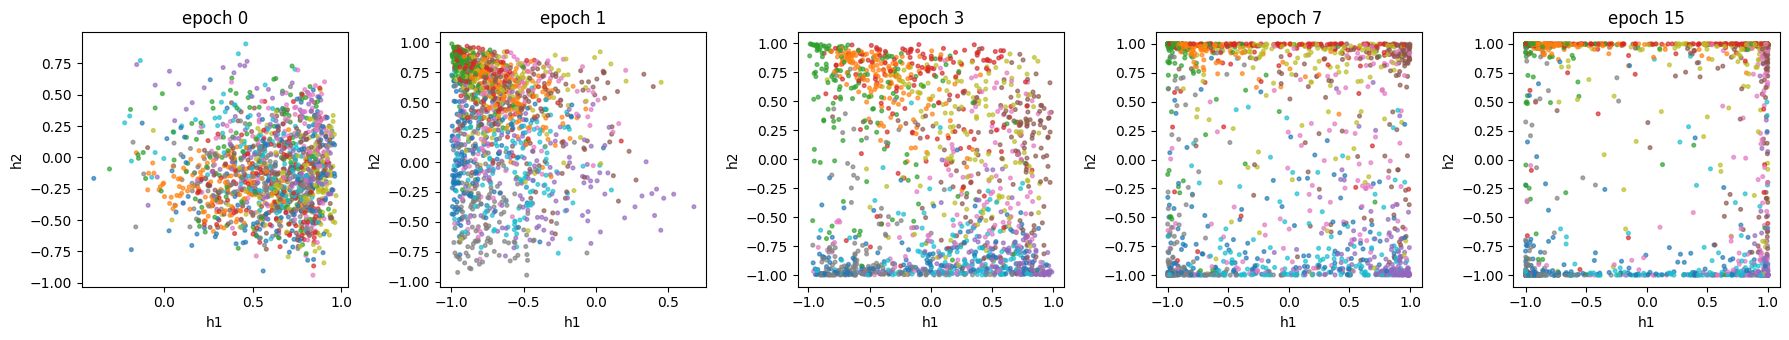

In [2]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
labels = y_train[:1500]
for ax, (epoch, H) in zip(axes, sorted(snaps.items())):
    sc = ax.scatter(H[:, 0], H[:, 1], c=labels, s=7, cmap="tab10", alpha=0.65)
    ax.set_title(f"epoch {epoch}")
    ax.set_xlabel("h1")
    ax.set_ylabel("h2")
plt.tight_layout()
plt.show()

## Engineering/business interpretation
In enterprise systems, hidden coordinates may become customer, document, transaction or product embeddings. Representation quality can determine whether downstream classifiers, retrieval systems or risk rules are simple and robust. Monitor not only final accuracy but also whether the representation drifts when production data changes.
